In [1]:
# ================================
# Cell 1: Imports & configuration
# ================================

import os
import re
import random
import math
import numpy as np
import pandas as pd
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Physical GPUs:", tf.config.list_physical_devices("GPU"))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- DATA PATHS (adjust if different on your Kaggle setup) ----
# Common Kaggle Flickr8k path:
#   /kaggle/input/flickr8k/Images/*.jpg
#   /kaggle/input/flickr8k/captions.txt
DATA_DIR = "/kaggle/input/flickr8k"
IMAGES_DIR = os.path.join(DATA_DIR, "Images")
CAPTIONS_FILE = os.path.join(DATA_DIR, "captions.txt")

print("DATA_DIR exists:", os.path.exists(DATA_DIR))
print("IMAGES_DIR exists:", os.path.exists(IMAGES_DIR))
print("CAPTIONS_FILE exists:", os.path.exists(CAPTIONS_FILE))

# ---- Hyperparameters ----
BATCH_SIZE = 64
BUFFER_SIZE = 1000
IMAGE_SIZE = (224, 224)   # For ResNet / EfficientNet
VOCAB_SIZE = 8000         # Max vocab size
MAX_LEN = 30              # Max caption length (incl <start>/<end>)
EMBED_DIM = 512           # Transformer d_model
FF_DIM = 1024             # Feed-forward layer size
NUM_HEADS = 8
NUM_DECODER_LAYERS = 3
EPOCHS = 30

# ---- Special tokens ----
START_TOKEN = "<start>"
END_TOKEN   = "<end>"

print("Config OK.")


2025-11-17 13:47:49.150215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763387269.357633      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763387269.417746      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.18.0
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
DATA_DIR exists: True
IMAGES_DIR exists: True
CAPTIONS_FILE exists: True
Config OK.


In [2]:
# ================================
# Cell 2: Inspect captions file
# ================================
print("Captions file path:", CAPTIONS_FILE)

# Show a few raw lines of the file to understand its structure
print("\nFirst 5 raw lines from captions.txt:\n" + "-"*50)
with open(CAPTIONS_FILE, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(5):
        line = f.readline()
        if not line:
            break
        print(repr(line))

print("\nNow trying a basic pandas read (no assumptions yet):")
try:
    df_preview = pd.read_csv(CAPTIONS_FILE)
    print("\nDataFrame shape:", df_preview.shape)
    print("Columns:", df_preview.columns.tolist())
    print(df_preview.head())
except Exception as e:
    print("\nPandas read_csv error:")
    print(e)


Captions file path: /kaggle/input/flickr8k/captions.txt

First 5 raw lines from captions.txt:
--------------------------------------------------
'image,caption\n'
'1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .\n'
'1000268201_693b08cb0e.jpg,A girl going into a wooden building .\n'
'1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .\n'
'1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .\n'

Now trying a basic pandas read (no assumptions yet):

DataFrame shape: (40455, 2)
Columns: ['image', 'caption']
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a

In [3]:
# ============================================
# Cell 3: Load, clean captions & split images
# ============================================

# Load full captions file (we already know it has 'image' and 'caption')
df = pd.read_csv(CAPTIONS_FILE)
print("Original df shape:", df.shape)
print(df.head())

# 1) Clean caption text
def clean_caption(text: str) -> str:
    text = text.lower()
    # Keep letters, numbers, apostrophes and spaces
    text = re.sub(r"[^a-z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_caption"] = df["caption"].apply(clean_caption)

# 2) Add <start> and <end> tokens
df["caption_proc"] = df["clean_caption"].apply(
    lambda c: f"{START_TOKEN} {c} {END_TOKEN}"
)

print("\nSample processed captions:")
print(df[["image", "caption_proc"]].head())

# 3) Build mapping: image -> list of captions
image_to_captions = {}
for img, cap in zip(df["image"], df["caption_proc"]):
    image_to_captions.setdefault(img, []).append(cap)

print("\nTotal unique images:", len(image_to_captions))

# Sanity check: one example image and its captions
some_img = next(iter(image_to_captions.keys()))
print("\nExample image:", some_img)
for c in image_to_captions[some_img]:
    print("  -", c)

# 4) Train / Val / Test split by image
all_images = list(image_to_captions.keys())
random.shuffle(all_images)

n_total = len(all_images)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)

train_images = all_images[:n_train]
val_images   = all_images[n_train:n_train + n_val]
test_images  = all_images[n_train + n_val:]

print("\nSplit sizes:")
print("  Total images:", n_total)
print("  Train images:", len(train_images))
print("  Val images:  ", len(val_images))
print("  Test images: ", len(test_images))


Original df shape: (40455, 2)
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  

Sample processed captions:
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                        caption_proc  
0  <start> a child in a pink dress is climbing up...  
1  <start> a girl going into a wooden building <end>  
2  <start> a little girl climbing into a wooden p...  
3  <st

In [4]:
# ============================================
# Cell 4: Text vectorization & tf.data dataset
# ============================================
from tensorflow.keras.layers import TextVectorization

# 1) Prepare a Dataset of all processed captions to adapt the vectorizer
all_captions_list = list(df["caption_proc"].values)
text_ds = tf.data.Dataset.from_tensor_slices(all_captions_list).batch(256)

# 2) Custom standardization (we already cleaned text, just lowercase)
def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return lowercase

vectorizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN,
    standardize=custom_standardization,
    ragged=False
)

# Adapt to the corpus
vectorizer.adapt(text_ds)

vocab = vectorizer.get_vocabulary()
vocab_size = len(vocab)
print("Vocabulary size (including special tokens):", vocab_size)

# Indices of special tokens (for later: generation, masking, etc.)
start_token_idx = vocab.index(START_TOKEN) if START_TOKEN in vocab else None
end_token_idx   = vocab.index(END_TOKEN)   if END_TOKEN   in vocab else None
print("START token idx:", start_token_idx)
print("END token idx:  ", end_token_idx)

# 3) Helper: build (image_path, caption_text) pairs for a split
def make_image_caption_pairs(image_list):
    pairs = []
    for img_name in image_list:
        caps = image_to_captions[img_name]
        img_path = os.path.join(IMAGES_DIR, img_name)
        for c in caps:
            pairs.append((img_path, c))
    return pairs

train_pairs = make_image_caption_pairs(train_images)
val_pairs   = make_image_caption_pairs(val_images)

print("Train pairs:", len(train_pairs))
print("Val pairs:  ", len(val_pairs))


# 4) Image loading & preprocessing
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # normalize to [0, 1]
    return img

def vectorize_caption(caption):
    return vectorizer(caption)


# 5) Map function: from (path, caption_text) to ((image_tensor, caption_in), caption_out)
def prepare_example(image_path, caption):
    img = load_image(image_path)
    cap_vec = vectorize_caption(caption)        # shape: (MAX_LEN,)
    # Teacher forcing:
    # Input sequence is everything except last token
    # Target sequence is everything except first token
    cap_in  = cap_vec[:-1]                      # shape: (MAX_LEN-1,)
    cap_out = cap_vec[1:]                       # shape: (MAX_LEN-1,)
    return (img, cap_in), cap_out


def make_dataset(pairs, shuffle=True):
    paths = [p[0] for p in pairs]
    caps  = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((paths, caps))
    if shuffle:
        ds = ds.shuffle(BUFFER_SIZE, seed=SEED)
    ds = ds.map(prepare_example, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_pairs, shuffle=True)
val_ds   = make_dataset(val_pairs, shuffle=False)

# 6) Sanity check: take one batch
for (img_batch, cap_in_batch), cap_out_batch in train_ds.take(1):
    print("Images batch shape:    ", img_batch.shape)      # (B, H, W, 3)
    print("Caption_in batch shape:", cap_in_batch.shape)   # (B, MAX_LEN-1)
    print("Caption_out batch shape:", cap_out_batch.shape) # (B, MAX_LEN-1)


I0000 00:00:1763387284.763007      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Vocabulary size (including special tokens): 8000
START token idx: 3
END token idx:   4
Train pairs: 32360
Val pairs:   4045
Images batch shape:     (64, 224, 224, 3)
Caption_in batch shape: (64, 29)
Caption_out batch shape: (64, 29)


In [5]:
# ============================================
# Cell 5: Multi-CNN encoder + Transformer decoder
# ============================================

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, EfficientNetB4
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess


# -------- Positional + Token Embedding for captions --------
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = layers.Embedding(max_len, embed_dim)
        self.max_len = max_len

    def call(self, x):
        # x: (batch, seq_len)
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        positions = self.pos_emb(positions)  # (seq_len, embed_dim)
        x = self.token_emb(x)                # (batch, seq_len, embed_dim)
        return x + positions


# -------- Single Transformer Decoder Layer --------
class DecoderLayer(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.self_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.cross_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
        self.dropout3 = layers.Dropout(rate)

    def call(self, x, enc_output, training=False):
        # x: (batch, target_seq_len, embed_dim)
        # enc_output: (batch, enc_seq_len, embed_dim)

        # 1) Look-ahead masked self-attention over target sequence
        seq_len = tf.shape(x)[1]
        look_ahead_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        # shape (seq_len, seq_len) will be broadcast to (batch, seq_len, seq_len)
        attn1 = self.self_attn(x, x, attention_mask=look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1)

        # 2) Cross-attention over encoder output (no padding mask needed for 2 tokens)
        attn2 = self.cross_attn(out1, enc_output, enc_output)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)

        # 3) Feed-forward network
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(out2 + ffn_output)
        return out3


# -------- Full Transformer Decoder (stack of layers) --------
class TransformerDecoder(layers.Layer):
    def __init__(self, num_layers, embed_dim, num_heads, ff_dim,
                 vocab_size, maximum_position_encoding, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_layers = num_layers
        self.token_pos_emb = TokenAndPositionEmbedding(maximum_position_encoding,
                                                       vocab_size, embed_dim)
        self.dec_layers = [
            DecoderLayer(embed_dim, num_heads, ff_dim, rate)
            for _ in range(num_layers)
        ]
        self.dropout = layers.Dropout(rate)

    def call(self, x, enc_output, training=False):
        # x: (batch, target_seq_len)
        # enc_output: (batch, enc_seq_len, embed_dim)
        x = self.token_pos_emb(x)  # (batch, target_seq_len, embed_dim)
        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.dec_layers[i](x, enc_output, training=training)

        # x: (batch, target_seq_len, embed_dim)
        return x


# -------- Multi-CNN Image Encoder (ResNet50 + EfficientNetB4) --------
class MultiCNNEncoder(layers.Layer):
    def __init__(self, embed_dim, train_backbones=False, **kwargs):
        super().__init__(**kwargs)
        # Base CNNs (ImageNet pretrained)
        self.resnet = ResNet50(
            include_top=False,
            weights="imagenet",
            pooling="avg",   # Global average pooling: (batch, 2048)
        )
        self.effnet = EfficientNetB4(
            include_top=False,
            weights="imagenet",
            pooling="avg",   # (batch, 1792)
        )

        # Optionally freeze them (good for Kaggle / smaller dataset)
        self.resnet.trainable = train_backbones
        self.effnet.trainable = train_backbones

        # Project each to embed_dim and then treat each as one "visual token"
        self.proj_resnet = layers.Dense(embed_dim)
        self.proj_effnet = layers.Dense(embed_dim)

    def call(self, x, training=False):
        # x: (batch, H, W, 3) in [0,1]
        # ResNet preprocess
        x_res = resnet_preprocess(x * 255.0)
        f_res = self.resnet(x_res, training=training)  # (batch, 2048)
        f_res = self.proj_resnet(f_res)                # (batch, embed_dim)

        # EfficientNet preprocess
        x_eff = effnet_preprocess(x * 255.0)
        f_eff = self.effnet(x_eff, training=training)  # (batch, 1792)
        f_eff = self.proj_effnet(f_eff)                # (batch, embed_dim)

        # Turn them into a sequence of 2 "visual tokens"
        f_res = tf.expand_dims(f_res, axis=1)          # (batch, 1, embed_dim)
        f_eff = tf.expand_dims(f_eff, axis=1)          # (batch, 1, embed_dim)

        enc_tokens = tf.concat([f_res, f_eff], axis=1) # (batch, 2, embed_dim)
        return enc_tokens


# -------- Build the full captioning model --------
def build_captioning_model(
    image_size=IMAGE_SIZE,
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embed_dim=EMBED_DIM,
    ff_dim=FF_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_DECODER_LAYERS,
):
    # Inputs
    image_input = layers.Input(
        shape=(image_size[0], image_size[1], 3),
        name="image_input"
    )
    caption_input = layers.Input(
        shape=(max_len - 1,),
        dtype="int32",
        name="caption_input"
    )

    # Encoder
    encoder = MultiCNNEncoder(embed_dim=embed_dim, train_backbones=False)
    enc_output = encoder(image_input)  # (batch, 2, embed_dim)

    # Decoder
    decoder = TransformerDecoder(
        num_layers=num_layers,
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        vocab_size=vocab_size,
        maximum_position_encoding=max_len,
    )
    dec_output = decoder(caption_input, enc_output)  # (batch, max_len-1, embed_dim)

    # Final projection to vocab logits
    output = layers.Dense(vocab_size, name="token_logits")(dec_output)

    model = Model(inputs=[image_input, caption_input], outputs=output, name="image_captioner")
    return model


caption_model = build_captioning_model()
caption_model.summary(line_length=120)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "image_captioner"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ image_input (InputLayer)          │ (None, 224, 224, 3)          │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ caption_input (InputLayer)        │ (None, 29)                   │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ multi_cnn_encoder                 │ (None, 2, 512)               │        43,228,639 │ image_input[0][0]         
│ (MultiCNNEncoder)                 │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_decoder               │ (None, 29, 512)              │        57,679,360 │ caption_input[0][0],      
│ (TransformerDecoder)              │                              │                   │ multi_cnn_encoder[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ token_logits (Dense)              │ (None, 29, 8000)             │         4,104,000 │ transformer_decoder[0][0] 
└───────────────────────────────────┴──────────────────────────────┴───────────────────┴───────────────────────────

 Total params: 105,011,999 (400.59 MB)

 Trainable params: 63,750,464 (243.19 MB)

 Non-trainable params: 41,261,535 (157.40 MB)

In [6]:
# Cell 6: Loss masking, compile & train
# ============================================

# Padding token index from TextVectorization is 0 by default
PAD_TOKEN_IDX = 0

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction="none"
)

def masked_loss(y_true, y_pred):
    """
    y_true: (batch, seq_len)
    y_pred: (batch, seq_len, vocab_size)
    We mask out loss where y_true == PAD_TOKEN_IDX.
    """
    # Compute basic per-token loss
    loss_ = loss_object(y_true, y_pred)  # (batch, seq_len)

    # Create mask: 1.0 for non-pad, 0.0 for pad
    mask = tf.cast(tf.not_equal(y_true, PAD_TOKEN_IDX), tf.float32)

    loss_ *= mask
    # Avoid division by zero
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask + 1e-7)

In [7]:
# ============================================
# Cell 7: Fix masked_accuracy dtype & recompile
# ============================================

# Reuse PAD_TOKEN_IDX and loss_object from before

def masked_accuracy(y_true, y_pred):
    """
    Token-level accuracy ignoring padding positions.
    Fix: cast y_true to int32 so it matches y_pred_ids dtype.
    """
    # Cast y_true to int32 to match argmax
    y_true = tf.cast(y_true, tf.int32)

    # Predicted token IDs (argmax over vocab)
    y_pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)  # (batch, seq_len)

    # Correct where equal
    matches = tf.cast(tf.equal(y_true, y_pred_ids), tf.float32)

    # Mask out padding
    mask = tf.cast(tf.not_equal(y_true, PAD_TOKEN_IDX), tf.float32)
    matches *= mask

    return tf.reduce_sum(matches) / tf.reduce_sum(mask + 1e-7)


# Re-compile model with the updated metric
caption_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=masked_loss,
    metrics=[masked_accuracy],
)

# Callbacks again
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    verbose=1,
    min_lr=1e-6,
)

print("Starting training (fixed metric)...")

history = caption_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
)

print("Training finished.")


Starting training (fixed metric)...
Epoch 1/30


I0000 00:00:1763387342.628668     105 service.cc:148] XLA service 0x7f1f3c022e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763387342.629324     105 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
W0000 00:00:1763387347.025808     105 assert_op.cc:38] Ignoring Assert operator compile_loss/masked_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1763387349.745637     105 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763387385.541135     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 5.2000 - masked_accuracy: 0.2527

W0000 00:00:1763387539.710613     104 assert_op.cc:38] Ignoring Assert operator compile_loss/masked_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - loss: 5.1982 - masked_accuracy: 0.2528

W0000 00:00:1763387583.742720     105 assert_op.cc:38] Ignoring Assert operator compile_loss/masked_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1763387604.315210     104 assert_op.cc:38] Ignoring Assert operator compile_loss/masked_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


506/506 ━━━━━━━━━━━━━━━━━━━━ 306s 452ms/step - loss: 5.1964 - masked_accuracy: 0.2529 - val_loss: 3.5196 - val_masked_accuracy: 0.3618 - learning_rate: 1.0000e-04
Epoch 2/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 165s 327ms/step - loss: 3.3266 - masked_accuracy: 0.3834 - val_loss: 3.1655 - val_masked_accuracy: 0.3925 - learning_rate: 1.0000e-04
Epoch 3/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 165s 327ms/step - loss: 2.9218 - masked_accuracy: 0.4217 - val_loss: 3.0336 - val_masked_accuracy: 0.4027 - learning_rate: 1.0000e-04
Epoch 4/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 165s 326ms/step - loss: 2.6572 - masked_accuracy: 0.4497 - val_loss: 2.9677 - val_masked_accuracy: 0.4083 - learning_rate: 1.0000e-04
Epoch 5/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 165s 327ms/step - loss: 2.4417 - masked_accuracy: 0.4761 - val_loss: 2.9321 - val_masked_accuracy: 0.4118 - learning_rate: 1.0000e-04
Epoch 6/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 2.2489 - masked_accuracy: 0.5020
Epoch 6: ReduceLROnPlateau reducing learning r

In [8]:
# ============================================
# Cell 8: Greedy & beam search captioning
# ============================================

import numpy as np

# 1) Index -> word mapping from the vectorizer vocabulary
index_to_word = np.array(vocab)

print("Vocab[0:10]:", index_to_word[:10])
print("START idx:", start_token_idx, "END idx:", end_token_idx, "PAD idx:", PAD_TOKEN_IDX)

# 2) Helper: load a single image and add batch dim (same as training)
def load_image_for_inference(image_path):
    img = load_image(image_path)          # (H, W, 3), already resized and normalized
    img = tf.expand_dims(img, axis=0)     # (1, H, W, 3)
    return img


# 3) Convert token IDs to human-readable caption (skip <start>, stop at <end>)
def tokens_to_caption(token_ids):
    words = []
    for idx in token_ids:
        if idx == PAD_TOKEN_IDX:
            continue
        if idx == start_token_idx:
            continue
        if idx == end_token_idx:
            break
        words.append(index_to_word[idx])
    return " ".join(words)


# 4) Greedy decoding: at each step, take argmax for next token
def generate_caption_greedy(image_path, max_len=MAX_LEN):
    img_tensor = load_image_for_inference(image_path)

    # Start with just <start> token
    seq = [start_token_idx]

    for t in range(max_len - 1):
        # Prepare caption_in of shape (1, max_len-1)
        cap_in = np.zeros((1, max_len - 1), dtype="int32")
        cap_in[0, :len(seq)] = seq

        # Predict logits for all positions
        preds = caption_model.predict([img_tensor, cap_in], verbose=0)
        # We want the position corresponding to the last token in seq
        next_token_logits = preds[0, len(seq) - 1, :]
        next_token = int(np.argmax(next_token_logits))

        seq.append(next_token)

        if next_token == end_token_idx:
            break

    caption = tokens_to_caption(seq)
    return caption


# 5) Beam search decoding
def generate_caption_beam(image_path, beam_width=5, max_len=MAX_LEN):
    img_tensor = load_image_for_inference(image_path)

    # Each beam is (sequence, log_prob, finished)
    beams = [([start_token_idx], 0.0, False)]

    for t in range(max_len - 1):
        # If all beams are finished, we can stop early
        if all(finished for (_, _, finished) in beams):
            break

        # Prepare batched inputs for current beams
        cur_size = len(beams)
        cap_in_batch = np.zeros((cur_size, max_len - 1), dtype="int32")
        for i, (seq, log_prob, finished) in enumerate(beams):
            cap_in_batch[i, :len(seq)] = seq

        # Repeat image tensor for each beam
        img_batch = tf.repeat(img_tensor, repeats=cur_size, axis=0)

        # Model prediction for all beams at once
        preds = caption_model.predict([img_batch, cap_in_batch], verbose=0)  # (cur_size, max_len-1, vocab_size)

        all_candidates = []

        for i, (seq, log_prob, finished) in enumerate(beams):
            if finished:
                # Keep finished beams as-is
                all_candidates.append((seq, log_prob, True))
                continue

            step_pos = len(seq) - 1
            logits_step = preds[i, step_pos, :]  # (vocab_size,)

            # Convert to log-probs with softmax
            log_probs = tf.nn.log_softmax(logits_step).numpy()

            # Get top beam_width token indices
            top_indices = np.argsort(log_probs)[-beam_width:]

            for token_idx in top_indices:
                token_idx = int(token_idx)
                if token_idx == PAD_TOKEN_IDX:
                    # Skip expanding with pad token
                    continue
                new_seq = seq + [token_idx]
                new_log_prob = log_prob + float(log_probs[token_idx])
                new_finished = (token_idx == end_token_idx)
                all_candidates.append((new_seq, new_log_prob, new_finished))

        # Sort all candidates by log_prob (descending) and keep top beam_width
        all_candidates.sort(key=lambda x: x[1], reverse=True)
        beams = all_candidates[:beam_width]

    # Select the best beam (highest log_prob)
    best_seq, best_log_prob, _ = beams[0]
    caption = tokens_to_caption(best_seq)
    return caption


# 6) Try on a few random validation images
print("\n=== Sample captions on validation images ===\n")
sample_val_imgs = random.sample(val_images, 3)

for img_name in sample_val_imgs:
    img_path = os.path.join(IMAGES_DIR, img_name)
    print("Image:", img_name)
    print("  Greedy:", generate_caption_greedy(img_path))
    print("  Beam  :", generate_caption_beam(img_path, beam_width=5))

    print("  References:")
    for ref in image_to_captions[img_name]:
        print("   -", ref)
    print()


Vocab[0:10]: ['' '[UNK]' 'a' '<start>' '<end>' 'in' 'the' 'on' 'is' 'and']
START idx: 3 END idx: 4 PAD idx: 0

=== Sample captions on validation images ===

Image: 537579448_a7f92cef58.jpg
  Greedy: a young girl is sitting on a green field
  Beam  : a little girl is sitting on the grass
  References:
   - <start> a little girl in a pink hat is playing with a soccer ball <end>
   - <start> a young girl is playing with a soccer ball in the grass <end>
   - <start> little girl with pink hat playing with a soccer ball <end>
   - <start> the little girl wearing a pink hat is bending down to pick up a soccer ball <end>
   - <start> young child playing with a soccer ball in a grassy area <end>

Image: 3491607076_922ec561d9.jpg
  Greedy: a woman in a blue suit is holding a sign while a woman watches
  Beam  : a woman in a cowboy hat is holding a sign
  References:
   - <start> a man holds a trophy on the stage <end>
   - <start> a race car driver accepts his trophy <end>
   - <start> a racer h

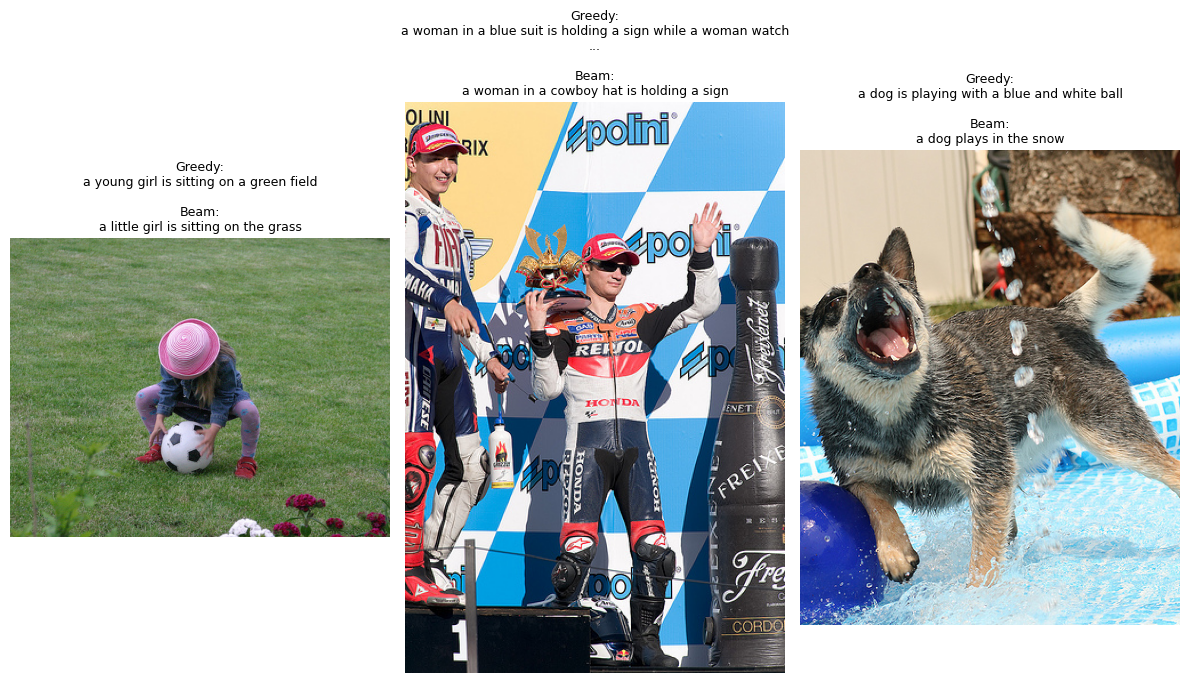

In [9]:
# ============================================
# Cell 9: Show sample images + captions
# ============================================
import matplotlib.pyplot as plt

# If you restarted the kernel and sample_val_imgs is gone, uncomment this:
# sample_val_imgs = random.sample(val_images, 3)

plt.figure(figsize=(12, 8))

for i, img_name in enumerate(sample_val_imgs):
    img_path = os.path.join(IMAGES_DIR, img_name)

    greedy_cap = generate_caption_greedy(img_path)
    beam_cap   = generate_caption_beam(img_path, beam_width=5)

    # Load raw image for display (not the preprocessed tensor)
    img = plt.imread(img_path)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        "Greedy:\n"
        + greedy_cap[:60]
        + ("\n..." if len(greedy_cap) > 60 else "")
        + "\n\nBeam:\n"
        + beam_cap[:60]
        + ("\n..." if len(beam_cap) > 60 else ""),
        fontsize=9,
    )

plt.tight_layout()
plt.show()


In [10]:
# ============================================
# Cell 10: Region-based Multi-CNN encoder + new model
# ============================================

from tensorflow.keras.applications import ResNet50, EfficientNetB4
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras import Model

# ---- Region-based Multi-CNN Encoder ----
class MultiCNNEncoderRegion(layers.Layer):
    """
    Uses ResNet50 and EfficientNetB4 WITHOUT global pooling.
    We keep the spatial feature maps and turn them into sequences of visual tokens.
    """
    def __init__(self, embed_dim, train_backbones=False, **kwargs):
        super().__init__(**kwargs)
        # Note: pooling=None so we get (H, W, C) feature maps
        self.resnet = ResNet50(
            include_top=False,
            weights="imagenet",
            pooling=None,
        )
        self.effnet = EfficientNetB4(
            include_top=False,
            weights="imagenet",
            pooling=None,
        )

        # Optionally fine-tune later; for now keep them frozen
        self.resnet.trainable = train_backbones
        self.effnet.trainable = train_backbones

        # Project channels to embed_dim for each token
        self.proj_resnet = layers.Dense(embed_dim)
        self.proj_effnet = layers.Dense(embed_dim)

    def call(self, x, training=False):
        """
        x: (batch, H, W, 3) in [0, 1]
        Returns: (batch, num_tokens, embed_dim)
        """
        # ---- ResNet branch ----
        x_res = resnet_preprocess(x * 255.0)
        f_res = self.resnet(x_res, training=training)          # (B, Hr, Wr, Cr)
        B_r, Hr, Wr, Cr = tf.unstack(tf.shape(f_res))
        # Flatten spatial dims -> tokens
        f_res = tf.reshape(f_res, [B_r, Hr * Wr, Cr])          # (B, Hr*Wr, Cr)
        f_res = self.proj_resnet(f_res)                        # (B, Hr*Wr, embed_dim)

        # ---- EfficientNet branch ----
        x_eff = effnet_preprocess(x * 255.0)
        f_eff = self.effnet(x_eff, training=training)          # (B, He, We, Ce)
        B_e, He, We, Ce = tf.unstack(tf.shape(f_eff))
        f_eff = tf.reshape(f_eff, [B_e, He * We, Ce])          # (B, He*We, Ce)
        f_eff = self.proj_effnet(f_eff)                        # (B, He*We, embed_dim)

        # ---- Concatenate tokens from both backbones ----
        enc_tokens = tf.concat([f_res, f_eff], axis=1)         # (B, Hr*Wr + He*We, embed_dim)
        return enc_tokens


# ---- New model builder using region encoder ----
def build_captioning_model_region(
    image_size=IMAGE_SIZE,
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embed_dim=EMBED_DIM,
    ff_dim=FF_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_DECODER_LAYERS,
):
    image_input = layers.Input(
        shape=(image_size[0], image_size[1], 3),
        name="image_input"
    )
    caption_input = layers.Input(
        shape=(max_len - 1,),
        dtype="int32",
        name="caption_input"
    )

    # Region-based encoder
    encoder = MultiCNNEncoderRegion(embed_dim=embed_dim, train_backbones=False)
    enc_output = encoder(image_input)  # (B, num_tokens, embed_dim)

    # Same transformer decoder as before
    decoder = TransformerDecoder(
        num_layers=num_layers,
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        vocab_size=vocab_size,
        maximum_position_encoding=max_len,
    )
    dec_output = decoder(caption_input, enc_output)  # (B, max_len-1, embed_dim)

    token_logits = layers.Dense(vocab_size, name="token_logits")(dec_output)

    model = Model(inputs=[image_input, caption_input],
                  outputs=token_logits,
                  name="image_captioner_region")
    return model


# Build new model
caption_model_region = build_captioning_model_region()
caption_model_region.summary(line_length=120)


Model: "image_captioner_region"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ image_input (InputLayer)          │ (None, 224, 224, 3)          │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ caption_input (InputLayer)        │ (None, 29)                   │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ multi_cnn_encoder_region          │ (None, 98, 512)              │        43,228,639 │ image_input[0][0]         
│ (MultiCNNEncoderRegion)           │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_decoder_1             │ (None, 29, 512)              │        57,679,360 │ caption_input[0][0],      
│ (TransformerDecoder)              │                              │                   │ multi_cnn_encoder_region[0
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ token_logits (Dense)              │ (None, 29, 8000)             │         4,104,000 │ transformer_decoder_1[0][0
└───────────────────────────────────┴──────────────────────────────┴───────────────────┴───────────────────────────

 Total params: 105,011,999 (400.59 MB)

 Trainable params: 63,750,464 (243.19 MB)

 Non-trainable params: 41,261,535 (157.40 MB)

In [11]:
# ============================================
# Cell 11: Compile & train region-based model
# ============================================

# Just to be safe: show we still have PAD_TOKEN_IDX
print("PAD_TOKEN_IDX:", PAD_TOKEN_IDX)

# Compile the region-based model
caption_model_region.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=masked_loss,
    metrics=[masked_accuracy],
)

# Callbacks: EarlyStopping & LR scheduler
early_stopping_region = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_region = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    verbose=1,
    min_lr=1e-6,
)

EPOCHS_REGION = 30  # you can lower to 20 if training is too slow

print("Starting training for region-based model...")

history_region = caption_model_region.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_REGION,
    callbacks=[early_stopping_region, reduce_lr_region],
)

print("Training finished for region-based model.")


PAD_TOKEN_IDX: 0
Starting training for region-based model...
Epoch 1/30


W0000 00:00:1763388873.685161     104 assert_op.cc:38] Ignoring Assert operator compile_loss/masked_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - loss: 5.1906 - masked_accuracy: 0.2544

W0000 00:00:1763389096.311571     107 assert_op.cc:38] Ignoring Assert operator compile_loss/masked_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - loss: 5.1888 - masked_accuracy: 0.2545

W0000 00:00:1763389136.886460     107 assert_op.cc:38] Ignoring Assert operator compile_loss/masked_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1763389159.034915     107 assert_op.cc:38] Ignoring Assert operator compile_loss/masked_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


506/506 ━━━━━━━━━━━━━━━━━━━━ 332s 514ms/step - loss: 5.1870 - masked_accuracy: 0.2546 - val_loss: 3.5169 - val_masked_accuracy: 0.3673 - learning_rate: 1.0000e-04
Epoch 2/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 202s 400ms/step - loss: 3.3127 - masked_accuracy: 0.3877 - val_loss: 3.1736 - val_masked_accuracy: 0.3893 - learning_rate: 1.0000e-04
Epoch 3/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 203s 400ms/step - loss: 2.8846 - masked_accuracy: 0.4297 - val_loss: 3.0449 - val_masked_accuracy: 0.4034 - learning_rate: 1.0000e-04
Epoch 4/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 203s 400ms/step - loss: 2.5954 - masked_accuracy: 0.4649 - val_loss: 3.0031 - val_masked_accuracy: 0.4062 - learning_rate: 1.0000e-04
Epoch 5/30
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - loss: 2.3538 - masked_accuracy: 0.4961
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
506/506 ━━━━━━━━━━━━━━━━━━━━ 202s 400ms/step - loss: 2.3537 - masked_accuracy: 0.4961 - val_loss: 3.0044 - val_masked_accuracy: 0.4056 - learnin

In [21]:
# ============================================
# Cell 12: Generate captions using region model
# ============================================

def generate_caption_greedy_region(image_path, max_len=MAX_LEN):
    img_tensor = load_image_for_inference(image_path)
    seq = [start_token_idx]

    for t in range(max_len - 1):
        cap_in = np.zeros((1, max_len - 1), dtype="int32")
        cap_in[0, :len(seq)] = seq

        preds = caption_model_region.predict([img_tensor, cap_in], verbose=0)
        next_logits = preds[0, len(seq) - 1, :]
        next_id = int(np.argmax(next_logits))

        seq.append(next_id)
        if next_id == end_token_idx:
            break

    return tokens_to_caption(seq)


def generate_caption_beam_region(image_path, beam_width=5, max_len=MAX_LEN):
    img_tensor = load_image_for_inference(image_path)
    beams = [([start_token_idx], 0.0, False)]

    for t in range(max_len - 1):
        if all(f for _, _, f in beams):
            break

        cap_batch = np.zeros((len(beams), max_len - 1), dtype="int32")
        for i, (seq, _, __) in enumerate(beams):
            cap_batch[i, :len(seq)] = seq

        img_batch = tf.repeat(img_tensor, repeats=len(beams), axis=0)
        preds = caption_model_region.predict([img_batch, cap_batch], verbose=0)

        candidates = []
        for i, (seq, logp, finished) in enumerate(beams):
            if finished:
                candidates.append((seq, logp, finished))
                continue

            step = len(seq) - 1
            logits = preds[i, step, :]
            log_probs = tf.nn.log_softmax(logits).numpy()

            top_ids = np.argsort(log_probs)[-beam_width:]
            for tid in top_ids:
                if tid == PAD_TOKEN_IDX:
                    continue
                new_seq = seq + [int(tid)]
                new_logp = logp + float(log_probs[tid])
                new_finished = (tid == end_token_idx)
                candidates.append((new_seq, new_logp, new_finished))

        candidates.sort(key=lambda x: x[1], reverse=True)
        beams = candidates[:beam_width]

    best_seq, _, _ = beams[0]
    return tokens_to_caption(best_seq)


# Test on 3 random validation images
print("\n=== Region Encoder Captions ===\n")
sample_val_imgs_region = random.sample(val_images, 3)

for img_name in sample_val_imgs_region:
    img_path = os.path.join(IMAGES_DIR, img_name)
    print("Image:", img_name)
    print("  Greedy:", generate_caption_greedy_region(img_path))
    print("  Beam  :", generate_caption_beam_region(img_path))
    print("  References:")
    for ref in image_to_captions[img_name]:
        print("   -", ref)
    print()



=== Region Encoder Captions ===

Image: 3052038928_9f53aa2084.jpg
  Greedy: a young boy and girl are sitting at a table
  Beam  : a group of young children are playing instruments
  References:
   - <start> a group of five young adults lounging indoors <end>
   - <start> a man and a woman sit on a couch and look at each other while three other men stand by <end>
   - <start> a small group of people standing while two sit on the couch <end>
   - <start> there are four men and one woman <end>
   - <start> three men are setting up a scene by measuring the lights for a couple sitting on a low couch <end>

Image: 2636514498_01fcc5f501.jpg
  Greedy: a baby in a blue shirt is holding a toy in his mouth
  Beam  : a baby in a blue shirt is holding a toy
  References:
   - <start> a child plays with a toy on a playground <end>
   - <start> a small child is wearing a blue outfit with blue shoes <end>
   - <start> a toddler plays on a playground <end>
   - <start> a young child is playing with a 

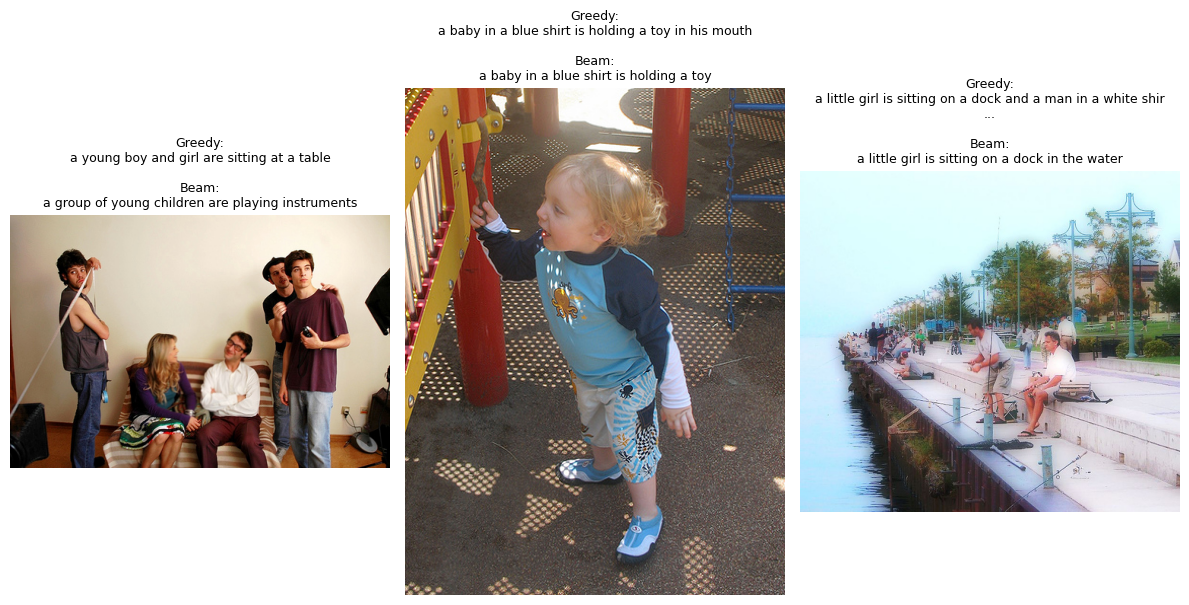

In [22]:
# ============================================
# Cell 13: Show images with region-model captions
# ============================================
import matplotlib.pyplot as plt

# If the variable is gone (after restart), recreate:
# sample_val_imgs_region = random.sample(val_images, 3)

plt.figure(figsize=(12, 8))

for i, img_name in enumerate(sample_val_imgs_region):
    img_path = os.path.join(IMAGES_DIR, img_name)

    greedy_cap = generate_caption_greedy_region(img_path)
    beam_cap   = generate_caption_beam_region(img_path, beam_width=5)

    img = plt.imread(img_path)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        "Greedy:\n"
        + greedy_cap[:60]
        + ("\n..." if len(greedy_cap) > 60 else "")
        + "\n\nBeam:\n"
        + beam_cap[:60]
        + ("\n..." if len(beam_cap) > 60 else ""),
        fontsize=9,
    )

plt.tight_layout()
plt.show()


In [14]:
# ============================================
# Cell 14: BLEU-1/2/3/4 evaluation on val set
# ============================================
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

chencherry = SmoothingFunction()

# How many validation images to evaluate (use None for all)
MAX_IMAGES = None  # e.g. 200 to speed up, or None for all

refs = []  # list of list-of-reference-token-lists
hyps = []  # list of hypothesis token lists

val_imgs_to_eval = val_images if MAX_IMAGES is None else val_images[:MAX_IMAGES]

print("Evaluating on", len(val_imgs_to_eval), "validation images...")

for idx, img_name in enumerate(val_imgs_to_eval):
    img_path = os.path.join(IMAGES_DIR, img_name)

    # Hypothesis from region model (beam search)
    hyp_sentence = generate_caption_beam_region(img_path, beam_width=5)
    hyp_tokens = hyp_sentence.split()

    # References (5 captions per image)
    img_refs = []
    for c in image_to_captions[img_name]:
        # Strip <start> / <end> and tokenize
        text = (
            c.replace(START_TOKEN, "")
             .replace(END_TOKEN, "")
             .strip()
        )
        img_refs.append(text.split())

    # Skip weird empty cases just in case
    if len(hyp_tokens) == 0 or len(img_refs) == 0:
        continue

    refs.append(img_refs)
    hyps.append(hyp_tokens)

    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx+1}/{len(val_imgs_to_eval)} images")

print("Finished collecting predictions, now computing BLEU scores...")

# BLEU-1
bleu1 = corpus_bleu(
    refs, hyps,
    weights=(1.0, 0.0, 0.0, 0.0),
    smoothing_function=chencherry.method1
)

# BLEU-2
bleu2 = corpus_bleu(
    refs, hyps,
    weights=(0.5, 0.5, 0.0, 0.0),
    smoothing_function=chencherry.method1
)

# BLEU-3
bleu3 = corpus_bleu(
    refs, hyps,
    weights=(0.33, 0.33, 0.34, 0.0),
    smoothing_function=chencherry.method1
)

# BLEU-4
bleu4 = corpus_bleu(
    refs, hyps,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=chencherry.method1
)

print("\nBLEU scores on validation set:")
print(f"  BLEU-1: {bleu1:.4f}")
print(f"  BLEU-2: {bleu2:.4f}")
print(f"  BLEU-3: {bleu3:.4f}")
print(f"  BLEU-4: {bleu4:.4f}")


Evaluating on 809 validation images...
  Processed 50/809 images
  Processed 100/809 images
  Processed 150/809 images
  Processed 200/809 images
  Processed 250/809 images
  Processed 300/809 images
  Processed 350/809 images
  Processed 400/809 images
  Processed 450/809 images
  Processed 500/809 images
  Processed 550/809 images
  Processed 600/809 images
  Processed 650/809 images
  Processed 700/809 images
  Processed 750/809 images
  Processed 800/809 images
Finished collecting predictions, now computing BLEU scores...

BLEU scores on validation set:
  BLEU-1: 0.6319
  BLEU-2: 0.4550
  BLEU-3: 0.3196
  BLEU-4: 0.2228


In [15]:
# ============================================
# Cell 15: Install captioning metric packages
# ============================================
!pip install git+https://github.com/salaniz/pycocoevalcap
!pip install rouge-score
!pip install nltk


  Cloning https://github.com/salaniz/pycocoevalcap to /tmp/pip-req-build-4bx7oys5
  Running command git clone --filter=blob:none --quiet https://github.com/salaniz/pycocoevalcap /tmp/pip-req-build-4bx7oys5
  Resolved https://github.com/salaniz/pycocoevalcap to commit a24f74c408c918f1f4ec34e9514bc8a76ce41ffd
  Preparing metadata (setup.py) ... done
  Created wheel for pycocoevalcap: filename=pycocoevalcap-1.2-py3-none-any.whl size=104312245 sha256=5644264f689115f74a5e105573593a1a5c8366029bbbb29429d2d43f72b5fa54
  Stored in directory: /tmp/pip-ephem-wheel-cache-3n79wwk4/wheels/d2/1f/44/6485e566f8ae3d42b56e7c05fd50a3bbb70a50b0e6e7c55212
Successfully built pycocoevalcap


In [16]:
# ============================================
# Cell 16: Import all metrics
# ============================================
from rouge_score import rouge_scorer
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice

meteor_scorer = Meteor()
cider_scorer = Cider()
spice_scorer = Spice()
scorer_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

import nltk
nltk.download('wordnet')


Progress: 384.5M / 384.5M (100.0%)
Extracting stanford-corenlp-3.6.0 ...
Done.


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [17]:
# ============================================
# Cell 17: Compute ROUGE-L, METEOR, CIDEr, SPICE
# ============================================

gts = {}   # ground truths
res = {}   # predictions

print("Generating captions for validation set...")

for idx, img_name in enumerate(val_images):
    img_path = os.path.join(IMAGES_DIR, img_name)

    # Use beam decoding
    hyp = generate_caption_beam_region(img_path, beam_width=5).strip()
    
    # Process references
    refs = []
    for c in image_to_captions[img_name]:
        clean = (
            c.replace("<start>", "")
             .replace("<end>", "")
             .strip()
        )
        refs.append(clean)

    res[idx] = [hyp]
    gts[idx] = refs

    if (idx + 1) % 50 == 0:
        print(f"  processed {idx+1}/{len(val_images)} images")

print("Finished. Computing metrics...\n")

# ---- METEOR ----
meteor_total = 0
for i in res.keys():
    score, _ = meteor_scorer.compute_score({i: gts[i]}, {i: res[i]})
    meteor_total += score
METEOR = meteor_total / len(res)

# ---- CIDEr ----
CIDEr, _ = cider_scorer.compute_score(gts, res)

# ---- SPICE ----
SPICE, _ = spice_scorer.compute_score(gts, res)

# ---- ROUGE-L ----
rouge_total = 0
for i in res.keys():
    hyp = res[i][0]
    ref_concat = " ".join(gts[i])
    rouge_total += scorer_rouge.score(ref_concat, hyp)["rougeL"].fmeasure
ROUGE_L = rouge_total / len(res)

print("===== VALIDATION METRICS =====")
print(f"ROUGE-L: {ROUGE_L:.4f}")
print(f"METEOR : {METEOR:.4f}")
print(f"CIDEr  : {CIDEr:.4f}")
print(f"SPICE  : {SPICE:.4f}")
print("================================")


Generating captions for validation set...
  processed 50/809 images
  processed 100/809 images
  processed 150/809 images
  processed 200/809 images
  processed 250/809 images
  processed 300/809 images
  processed 350/809 images
  processed 400/809 images
  processed 450/809 images
  processed 500/809 images
  processed 550/809 images
  processed 600/809 images
  processed 650/809 images
  processed 700/809 images
  processed 750/809 images
  processed 800/809 images
Finished. Computing metrics...



Parsing reference captions
Initiating Stanford parsing pipeline
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator tokenize
[main] INFO edu.stanford.nlp.pipeline.TokenizerAnnotator - TokenizerAnnotator: No tokenizer type provided. Defaulting to PTBTokenizer.
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ssplit
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator parse
[main] INFO edu.stanford.nlp.parser.common.ParserGrammar - Loading parser from serialized file edu/stanford/nlp/models/lexparser/englishPCFG.ser.gz ... 
done [0.7 sec].
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator lemma
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ner
Loading classifier from edu/stanford/nlp/models/ner/english.all.3class.distsim.crf.ser.gz ... done [1.3 sec].
Loading classifier from edu/stanford/nlp/models/ner/english.muc.7class.distsim.crf.ser.gz ... done [0.7 sec].
Loading classif

SPICE evaluation took: 1.836 min
===== VALIDATION METRICS =====
ROUGE-L: 0.1835
METEOR : 0.2155
CIDEr  : 0.5484
SPICE  : 0.1472


In [18]:
caption_model_region.save_weights("flickr8k_region_best.weights.h5")
print("✅ Weights saved as flickr8k_region_best.weights.h5")


✅ Weights saved as flickr8k_region_best.weights.h5


***Predictions***

In [19]:
caption_model_region = build_captioning_model_region(
    image_size=IMAGE_SIZE,
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embed_dim=EMBED_DIM,
    ff_dim=FF_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_DECODER_LAYERS,
)


In [20]:
caption_model_region.load_weights("flickr8k_region_best.weights.h5")
print("✅ Weights loaded successfully.")

✅ Weights loaded successfully.
